# Exploratory Data Analysis
Tujuan : Menganalisis data untuk memperoleh insight.

## 1. Dataset Overview
Tujuan : Melihat gambaran besar dari dataset.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/processed/telco_clean.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,...,29.85,29.85,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,56.95,1889.50,0,0,0,0,0,0,0,1
2,1,0,0,0,2,1,1,1,0,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,1,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,1,0,0,1,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64  
 8   DeviceProtection                       7032 non-null   int64  
 9   TechSupport                            7032 non-null   int64  
 10  StreamingTV                            7032 non-null   int64  
 11  StreamingMovies

In [22]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.286547,0.344852,0.343857,0.290102,...,64.798208,2283.300441,0.265785,0.096701,0.421928,0.440273,0.216155,0.216297,0.336320,0.228100
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.452180,0.475354,0.475028,0.453842,...,30.085974,2266.771362,0.441782,0.295571,0.493902,0.496455,0.411650,0.411748,0.472483,0.419637
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,35.587500,401.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,70.350000,1397.475000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,89.862500,3794.737500,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Target Analysis
Tujuan : Menganalisis informasi mengenai target.

In [23]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

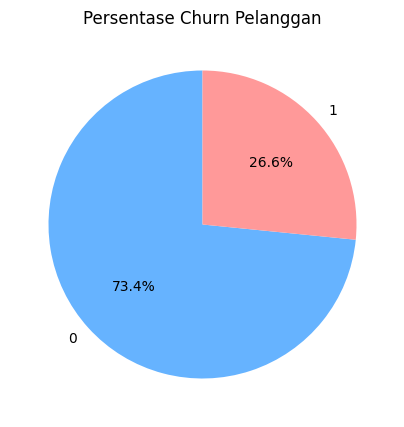

In [24]:
plt.figure(figsize=(5, 5))
plt.pie(df["Churn"].value_counts(), labels=df["Churn"].value_counts().index, autopct="%1.1f%%", startangle=90, colors=["#66b3ff","#ff9999"])

plt.title("Persentase Churn Pelanggan")

plt.show()

Insight : Berdasarkan grafik pai tersebut, terdapat 26,6% pelanggan yang memutuskan untuk berhenti berlangganan (churn), sementara mayoritas pelanggan sebesar 73,4% memilih untuk tetap bertahan.

## 3. Numerical Features Analysis
Tujuan : Menganalisis beberapa fitur numerik dalam data.

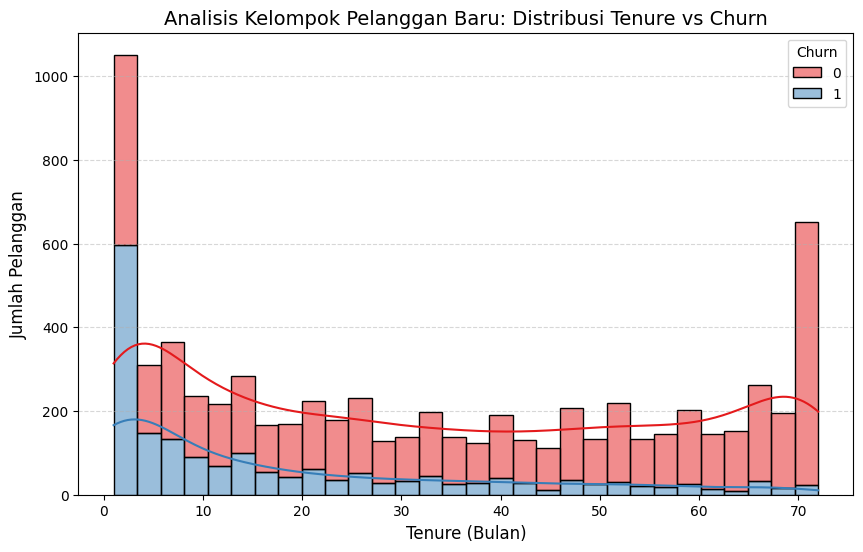

In [25]:
plt.figure(figsize=(10, 6))

# Membuat histogram bertumpuk untuk kolom tenure
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", palette="Set1", kde=True, bins=30)

plt.title("Analisis Kelompok Pelanggan Baru: Distribusi Tenure vs Churn", fontsize=14)
plt.xlabel("Tenure (Bulan)", fontsize=12)
plt.ylabel("Jumlah Pelanggan", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Insight : Grafik tersebut mengonfirmasi bahwa pelanggan baru memiliki risiko churn yang sangat tinggi, dengan lonjakan kasus churn (kategori 1) paling signifikan terjadi pada masa awal berlangganan (tenure 0–3 bulan) yang mencapai hampir 600 pelanggan. Namun, tingkat churn ini menurun drastis dan cenderung stabil setelah melewati tahun pertama, yang mengindikasikan bahwa loyalitas pelanggan berhasil terbentuk seiring berjalannya waktu. Selain itu, terdapat retensi jangka panjang yang sangat kuat pada kelompok pelanggan setia dengan masa berlangganan di atas 70 bulan, sehingga perusahaan disarankan untuk memprioritaskan strategi intervensi dan program onboarding khusus pada 12 bulan pertama guna menekan angka kehilangan pelanggan baru secara efektif.

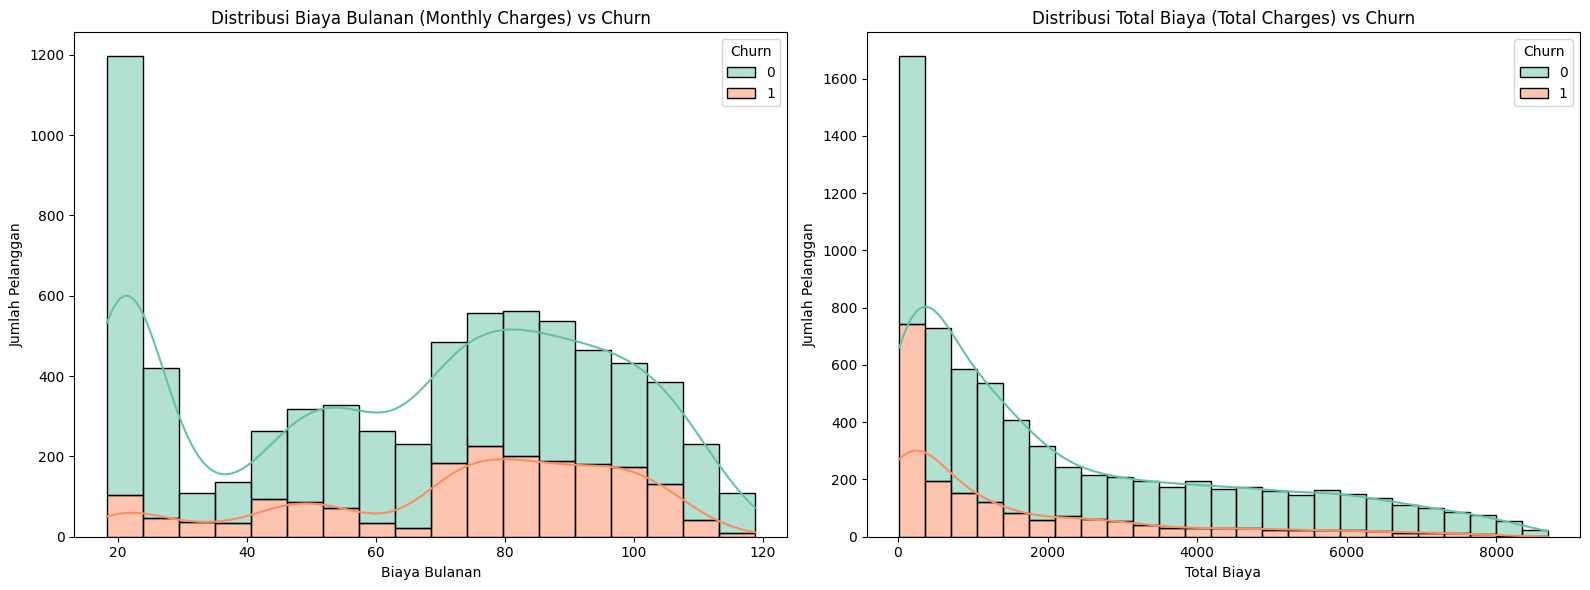

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram untuk MonthlyCharges
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack", palette="Set2", kde=True, ax=axes[0])
axes[0].set_title("Distribusi Biaya Bulanan (Monthly Charges) vs Churn")
axes[0].set_xlabel("Biaya Bulanan")
axes[0].set_ylabel("Jumlah Pelanggan")

# Histogram untuk TotalCharges
sns.histplot(data=df, x="TotalCharges", hue="Churn", multiple="stack", palette="Set2", kde=True, ax=axes[1])
axes[1].set_title("Distribusi Total Biaya (Total Charges) vs Churn")
axes[1].set_xlabel("Total Biaya")
axes[1].set_ylabel("Jumlah Pelanggan")

plt.tight_layout()
plt.show()

Insight : Visualisasi menunjukkan bahwa biaya bulanan yang tinggi menjadi pemicu utama churn bagi pelanggan dengan akumulasi pengeluaran yang masih rendah (pelanggan baru). Berdasarkan grafik MonthlyCharges (kiri), angka churn (kategori 1) mendominasi secara signifikan pada segmen biaya bulanan tinggi, khususnya pada rentang 70 hingga 100 satuan mata uang. Pola ini diperkuat oleh grafik TotalCharges (kanan) yang memperlihatkan bahwa mayoritas kasus churn menumpuk di area pengeluaran total yang sangat rendah (di bawah 1.000 satuan mata uang). Kombinasi kedua data ini mengindikasikan bahwa pelanggan baru yang langsung dikenakan tarif bulanan mahal merasa tidak mendapatkan nilai (value) yang sepadan, sehingga mereka memilih berhenti berlangganan di awal periode kontrak.

## 4. Features vs Churn
Tujuan : Menganalisis beberapa fitur yang mempengaruhi churn.

C:\Users\Asus\AppData\Local\Temp\ipykernel_11304\2685751309.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=feature, hue="Churn", data=df, shade=True, palette="Set2", ax=axes[i])
C:\Users\Asus\AppData\Local\Temp\ipykernel_11304\2685751309.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=feature, hue="Churn", data=df, shade=True, palette="Set2", ax=axes[i])


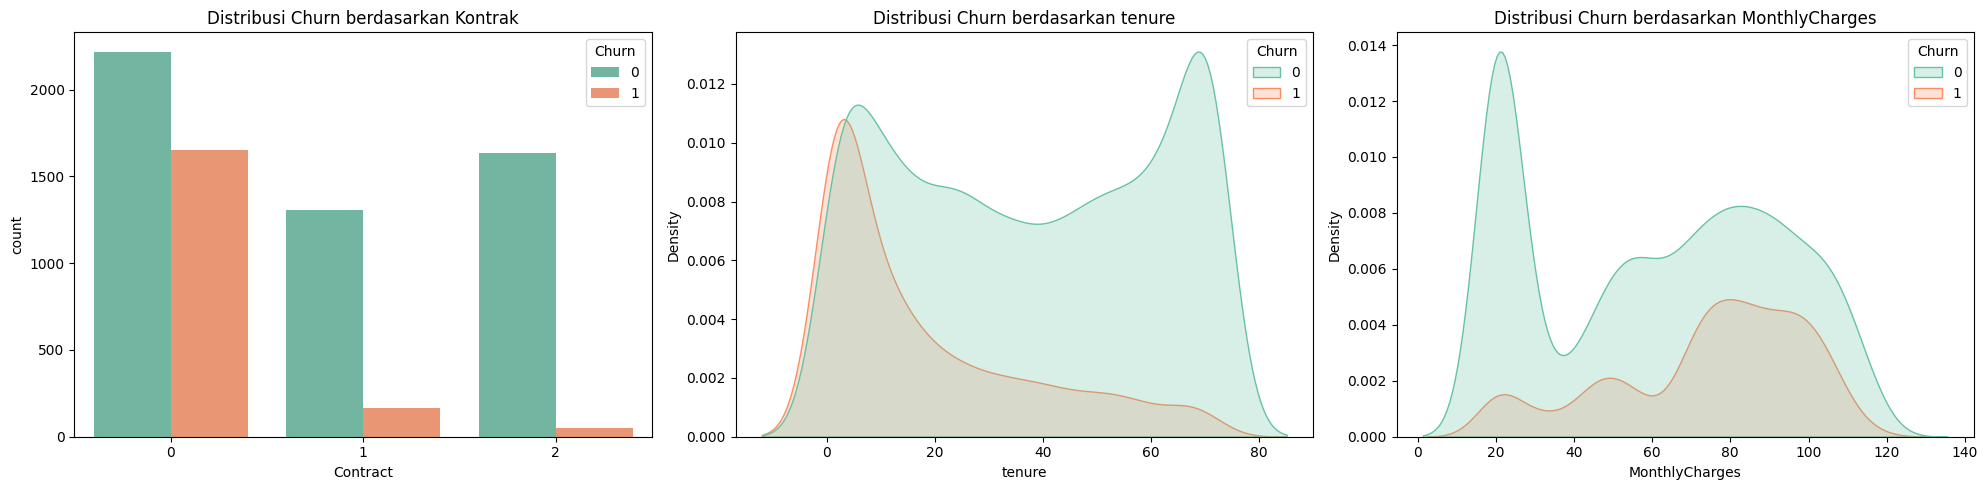

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
features = ["Contract", "tenure", "MonthlyCharges"]

for i, feature in enumerate(features):
    if feature == "Contract":
        # Data Kategorikal: Gunakan countplot
        sns.countplot(x=feature, hue="Churn", data=df, palette="Set2", ax=axes[i])
        axes[i].set_title("Distribusi Churn berdasarkan Kontrak")
    else:
        # Data Numerik (tenure & MonthlyCharges): Gunakan kdeplot / histplot
        sns.kdeplot(x=feature, hue="Churn", data=df, shade=True, palette="Set2", ax=axes[i])
        axes[i].set_title(f"Distribusi Churn berdasarkan {feature}")

plt.tight_layout()
plt.show()

Insight: Grafik tersebut menunjukkan bahwa profil utama pelanggan yang paling rentan melakukan churn adalah pelanggan baru dengan tipe kontrak bulanan (Month-to-month) yang dibebani biaya layanan yang tinggi, terutama pada kisaran nilai 70 hingga 100. Risiko hilangnya pelanggan ini berada pada titik paling kritis dalam kurun waktu 0 hingga 10 bulan pertama masa berlangganan, sedangkan pelanggan lama dengan kontrak jangka panjang dan biaya bulanan yang lebih rendah terbukti memiliki tingkat loyalitas yang jauh lebih stabil dan aman dari risiko churn.

## 5. Correlation
Tujuan: Menganalisis korelasi antar fitur.

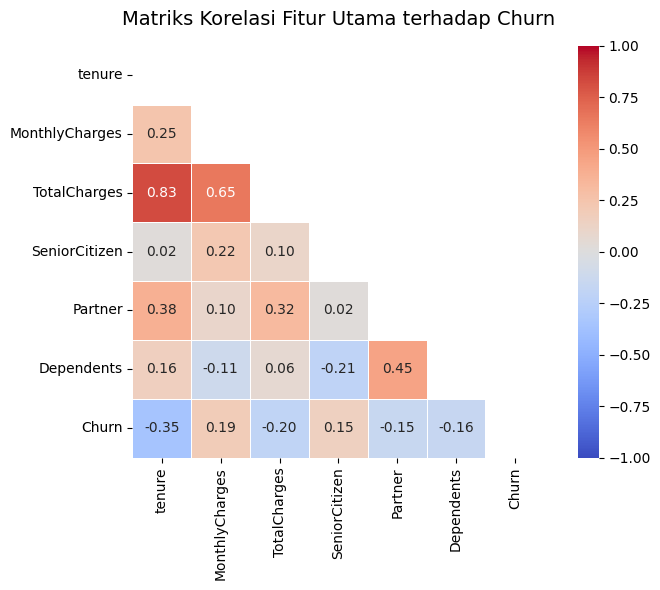

In [28]:
fitur_utama = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Partner', 'Dependents', 'Churn']
corr_simple = df[fitur_utama].corr(numeric_only=True)

# 2. Buat mask segitiga atas untuk menyembunyikan duplikasi grafik yang cermin
mask = np.triu(np.ones_like(corr_simple, dtype=bool))

# 3. Gambar heatmap yang bersih
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_simple, 
    mask=mask,          # Menyembunyikan setengah grafik yang tidak perlu
    annot=True,         # Menampilkan angka korelasi langsung di kotak
    fmt=".2f",          # Membatasi angka desimal agar rapi
    cmap="coolwarm",    # Warna kontras (merah = positif, biru = negatif)
    vmin=-1, vmax=1,    # Skala standar korelasi
    square=True,        # Memastikan kotak berbentuk simetris
    linewidths=0.5      # Memberi garis pembatas tipis antar kotak
)

plt.title("Matriks Korelasi Fitur Utama terhadap Churn", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Insight: Berdasarkan matriks korelasi tersebut, faktor terkuat yang menahan pelanggan agar tidak pindah adalah masa berlangganan (tenure dengan korelasi -0.35), di mana semakin lama seseorang menjadi pelanggan, kecenderungan mereka untuk melakukan churn akan semakin menurun secara signifikan. Sebaliknya, biaya bulanan (MonthlyCharges dengan korelasi 0.19) menjadi pemicu utama yang mendorong pelanggan untuk berhenti berlangganan. Selain itu, grafik ini juga mendeteksi adanya indikasi multikolinearitas yang sangat kuat antara tenure dan TotalCharges (0.83), yang berarti kedua fitur tersebut membawa informasi yang hampir serupa dan perlu diwaspadai saat melatih model machine learning nanti.